In [88]:
# Importing libraries for data processing, visualization, model building,
# handling imbalance, and evaluating machine learning models.
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,accuracy_score,confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from xgboost.sklearn import XGBClassifier
import shap


In [3]:
# Load dataset and reads a CSV file into a pandas DataFrame.
df=pd.read_csv("/content/drive/MyDrive/data science/Dataset/Bankruptcies.csv")

# EDA and preprocessing

In [4]:
df.head()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


 The first five rows of the dataset.

In [5]:
df.tail()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
6814,0,0.493687,0.539468,0.543230,0.604455,0.604462,0.998992,0.797409,0.809331,0.303510,...,0.799927,0.000466,0.623620,0.604455,0.840359,0.279606,0.027064,0.566193,1,0.029890
6815,0,0.475162,0.538269,0.524172,0.598308,0.598308,0.998992,0.797414,0.809327,0.303520,...,0.799748,0.001959,0.623931,0.598306,0.840306,0.278132,0.027009,0.566018,1,0.038284
6816,0,0.472725,0.533744,0.520638,0.610444,0.610213,0.998984,0.797401,0.809317,0.303512,...,0.797778,0.002840,0.624156,0.610441,0.840138,0.275789,0.026791,0.565158,1,0.097649
6817,0,0.506264,0.559911,0.554045,0.607850,0.607850,0.999074,0.797500,0.809399,0.303498,...,0.811808,0.002837,0.623957,0.607846,0.841084,0.277547,0.026822,0.565302,1,0.044009
6818,0,0.493053,0.570105,0.549548,0.627409,0.627409,0.998080,0.801987,0.813800,0.313415,...,0.815956,0.000707,0.626680,0.627408,0.841019,0.275114,0.026793,0.565167,1,0.233902


The last five rows of the dataset.

In [6]:
df.shape

(6819, 96)

6819 rows and 96 column

In [7]:
df.isna().sum().value_counts()

,count
0,96


There are missing no value.

In [8]:
df.dtypes.value_counts()

,count
float64,93
int64,3


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   Bankrupt?                                                 6819 non-null   int64  
 1    ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2    ROA(A) before interest and % after tax                   6819 non-null   float64
 3    ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4    Operating Gross Margin                                   6819 non-null   float64
 5    Realized Sales Gross Margin                              6819 non-null   float64
 6    Operating Profit Rate                                    6819 non-null   float64
 7    Pre-tax net Interest Rate                                6819 non-null   float64
 8    After-tax net Int

In [10]:
df.describe()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
count,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,...,6819.000000,6.819000e+03,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.0,6819.000000
mean,0.032263,0.505180,0.558625,0.553589,0.607948,0.607929,0.998755,0.797190,0.809084,0.303623,...,0.807760,1.862942e+07,0.623915,0.607946,0.840402,0.280365,0.027541,0.565358,1.0,0.047578
std,0.176710,0.060686,0.065620,0.061595,0.016934,0.016916,0.013010,0.012869,0.013601,0.011163,...,0.040332,3.764501e+08,0.012290,0.016934,0.014523,0.014463,0.015668,0.013214,0.0,0.050014
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.000000
25%,0.000000,0.476527,0.535543,0.527277,0.600445,0.600434,0.998969,0.797386,0.809312,0.303466,...,0.796750,9.036205e-04,0.623636,0.600443,0.840115,0.276944,0.026791,0.565158,1.0,0.024477
50%,0.000000,0.502706,0.559802,0.552278,0.605997,0.605976,0.999022,0.797464,0.809375,0.303525,...,0.810619,2.085213e-03,0.623879,0.605998,0.841179,0.278778,0.026808,0.565252,1.0,0.033798
75%,0.000000,0.535563,0.589157,0.584105,0.613914,0.613842,0.999095,0.797579,0.809469,0.303585,...,0.826455,5.269777e-03,0.624168,0.613913,0.842357,0.281449,0.026913,0.565725,1.0,0.052838
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,9.820000e+09,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000


In [11]:
df.nunique()

,0
Bankrupt?,2
ROA(C) before interest and depreciation before interest,3333
ROA(A) before interest and % after tax,3151
ROA(B) before interest and depreciation after tax,3160
Operating Gross Margin,3781
...,...
Liability to Equity,6819
Degree of Financial Leverage (DFL),6240
Interest Coverage Ratio (Interest expense to EBIT),6240
Net Income Flag,1


In [12]:
df.duplicated().sum()

np.int64(0)

There are 0 duplicates value

In [13]:
selector = VarianceThreshold(threshold=0.01)
selector.fit(df)

VarianceThreshold(threshold=0.01)

Removes features with very low variance (below 0.01) since they carry little to no useful information for the model.

In [14]:
low_variance_cols = df.columns[~selector.get_support()]
low_variance_cols

Index([' ROA(C) before interest and depreciation before interest',
       ' ROA(A) before interest and % after tax',
       ' ROA(B) before interest and depreciation after tax',
       ' Operating Gross Margin', ' Realized Sales Gross Margin',
       ' Operating Profit Rate', ' Pre-tax net Interest Rate',
       ' After-tax net Interest Rate',
       ' Non-industry income and expenditure/revenue',
       ' Continuous interest rate (after tax)', ' Cash flow rate',
       ' Net Value Per Share (B)', ' Net Value Per Share (A)',
       ' Net Value Per Share (C)', ' Persistent EPS in the Last Four Seasons',
       ' Cash Flow Per Share', ' Operating Profit Per Share (Yuan ¥)',
       ' Per Share Net profit before tax (Yuan ¥)',
       ' Realized Sales Gross Profit Growth Rate',
       ' Operating Profit Growth Rate', ' After-tax Net Profit Growth Rate',
       ' Regular Net Profit Growth Rate', ' Continuous Net Profit Growth Rate',
       ' Total Asset Return Growth Rate Ratio', ' Cash Rein

In [15]:
df = df.drop(columns=low_variance_cols)

In [16]:
corr = df.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

Computes absolute correlations and keeps only the upper triangle of the matrix to identify highly correlated (redundant) features without duplication.

In [17]:
high_corr_cols = [col for col in upper.columns if any(upper[col] > 0.9)]
high_corr_cols

[' Current Liability to Liability']

In [18]:
df = df.drop(columns=high_corr_cols)

In [19]:
df.shape

(6819, 31)

In [20]:
df.columns

Index(['Bankrupt?', ' Operating Expense Rate',
       ' Research and development expense rate',
       ' Interest-bearing debt interest rate', ' Tax rate (A)',
       ' Revenue Per Share (Yuan ¥)', ' Total Asset Growth Rate',
       ' Net Value Growth Rate', ' Current Ratio', ' Quick Ratio',
       ' Total debt/Total net worth', ' Total Asset Turnover',
       ' Accounts Receivable Turnover', ' Average Collection Days',
       ' Inventory Turnover Rate (times)', ' Fixed Assets Turnover Frequency',
       ' Revenue per person', ' Allocation rate per person',
       ' Quick Assets/Total Assets', ' Current Assets/Total Assets',
       ' Cash/Total Assets', ' Quick Assets/Current Liability',
       ' Cash/Current Liability', ' Inventory/Current Liability',
       ' Current Liabilities/Liability',
       ' Long-term Liability to Current Assets',
       ' Current Asset Turnover Rate', ' Quick Asset Turnover Rate',
       ' Cash Turnover Rate', ' Fixed Assets to Assets',
       ' Total assets

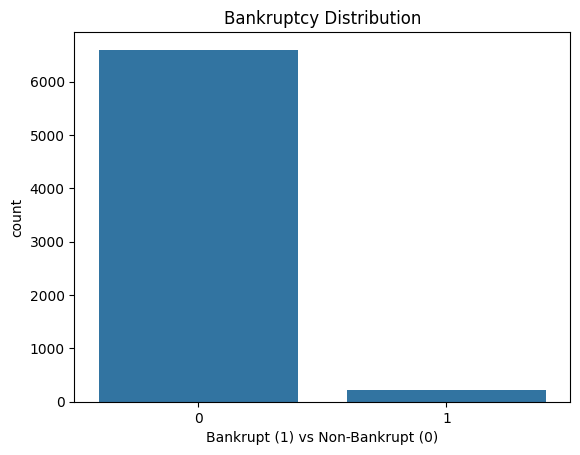

In [21]:
sns.countplot(x=df['Bankrupt?'])
plt.title("Bankruptcy Distribution")
plt.xlabel("Bankrupt (1) vs Non-Bankrupt (0)")
plt.show()

The dataset is highly imbalanced, with significantly more non-bankrupt (0) companies than bankrupt (1), which can bias the model toward the majority class.

<Axes: >

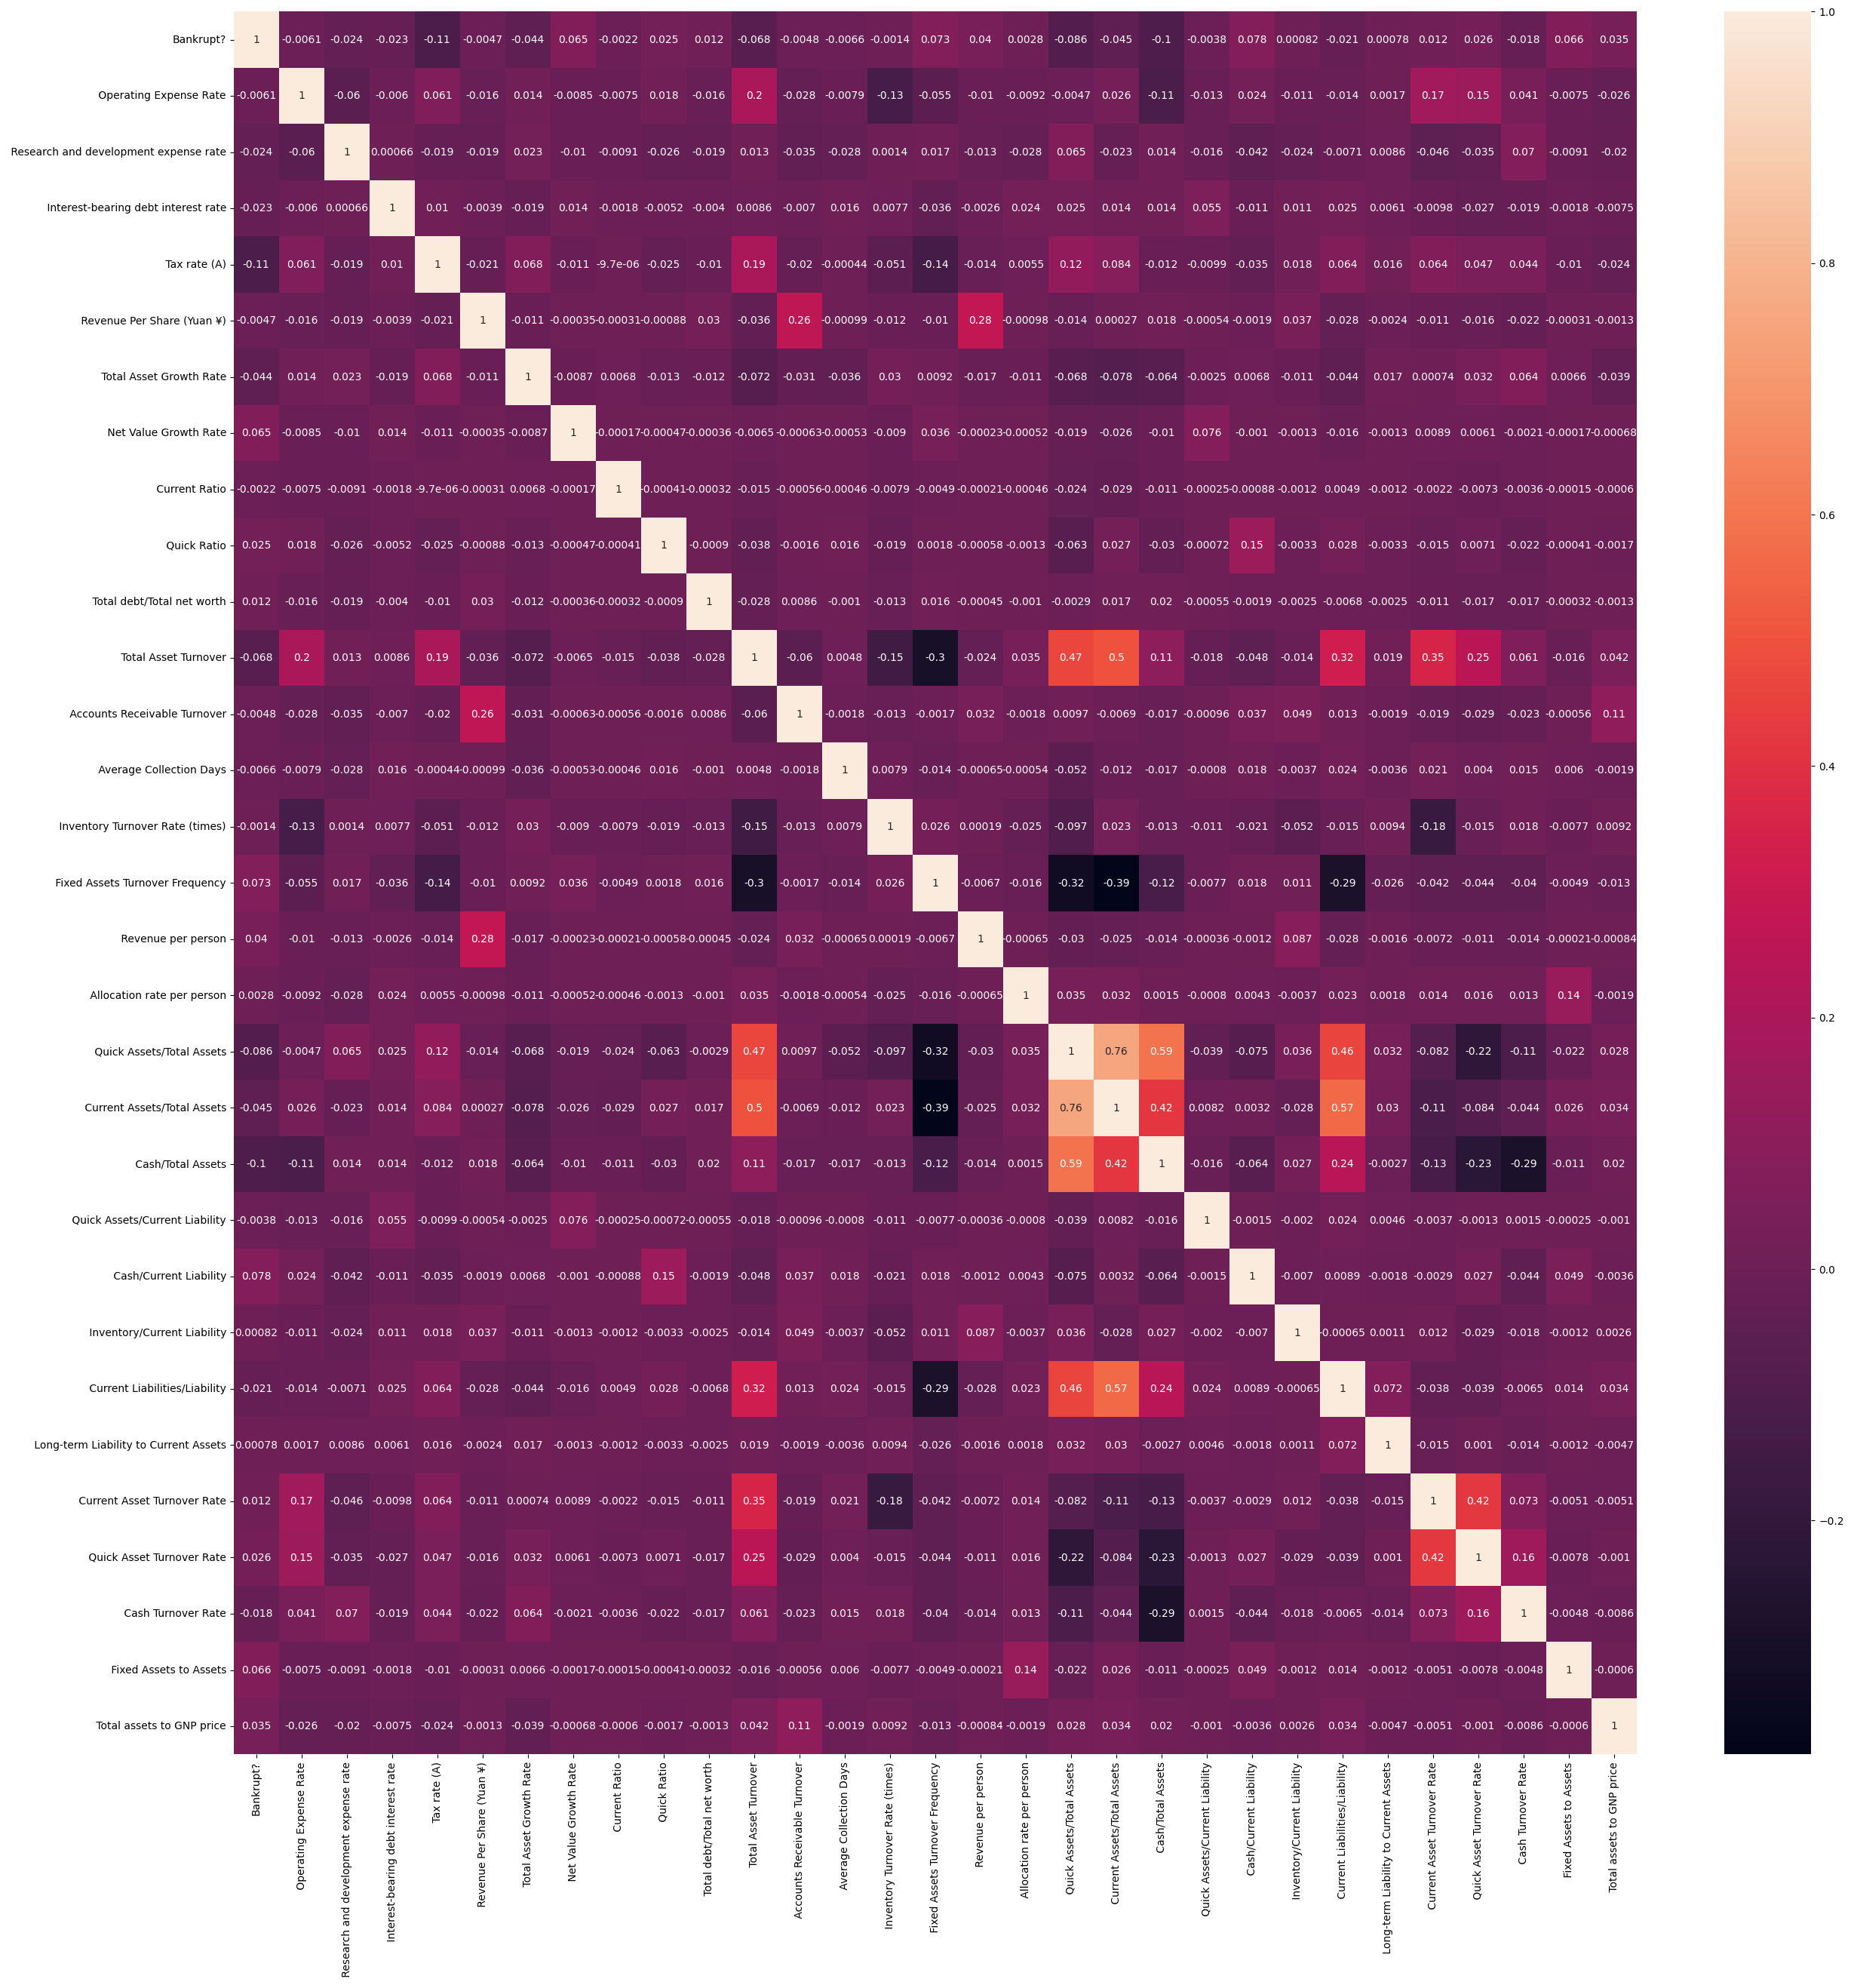

In [22]:
cor=df.corr(numeric_only=True)
plt.figure(figsize=(30,30))
sns.heatmap(cor,annot=True)


The correlation heatmap shows relationships between features, helping identify highly correlated (redundant) variables that can be removed to reduce multicollinearity.

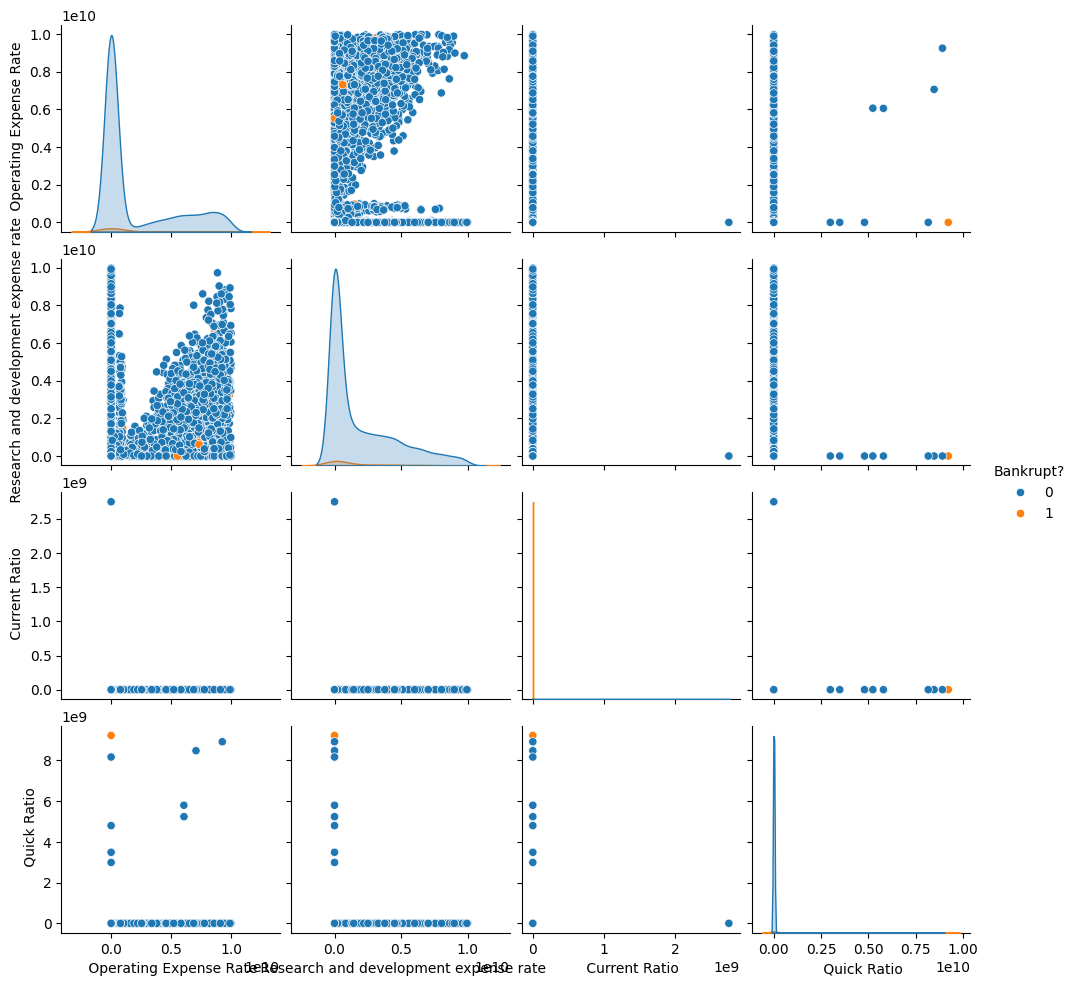

In [23]:
important_cols = [' Operating Expense Rate', ' Research and development expense rate', ' Current Ratio', ' Quick Ratio']
sns.pairplot(df[important_cols + ['Bankrupt?']], hue='Bankrupt?')
plt.show()

The pairplot visualizes relationships between key financial features and shows how bankrupt and non-bankrupt companies are distributed, helping identify patterns and separability between classes.

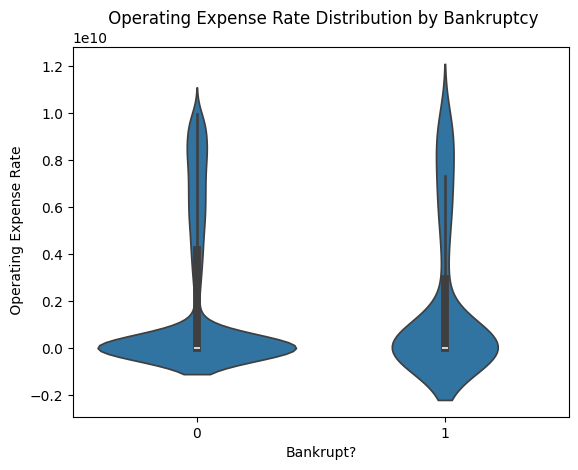

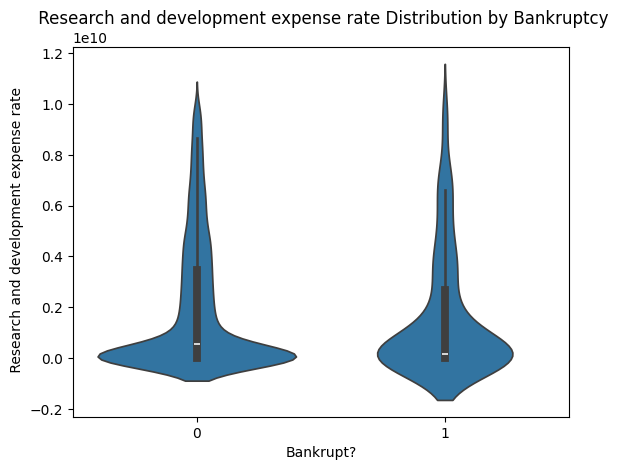

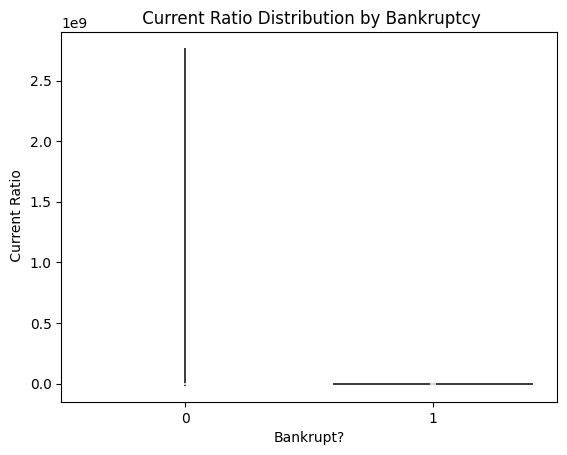

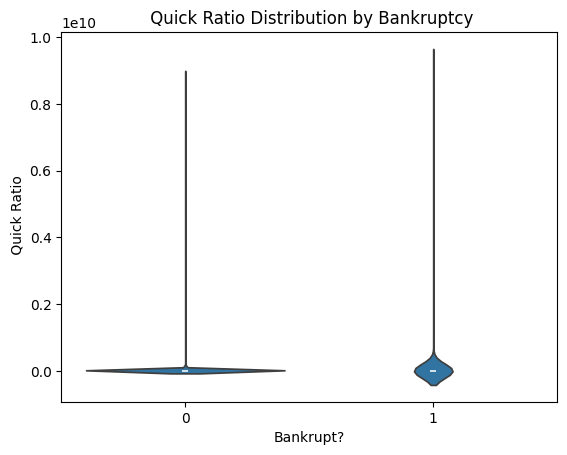

In [24]:
for col in important_cols:
    sns.violinplot(x='Bankrupt?', y=col, data=df)
    plt.title(f"{col} Distribution by Bankruptcy")
    plt.show()

The violin plots show the distribution of financial features across bankrupt and non-bankrupt companies, highlighting skewness, outliers, and differences in data spread between the two classes.

In [26]:
x=df.drop(columns=['Bankrupt?'])
y=df['Bankrupt?']

The dataset is split into input features (X) by removing the target column and the target variable (y) containing the bankruptcy labels.

In [28]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=123,stratify=y)

The data is divided into training and testing sets with stratification to maintain class balance, ensuring reliable model evaluation.

# Logisitic regression

In [30]:
lr=LogisticRegression()

In [31]:
lr.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [32]:
y_pred_log=lr.predict(x_test)

In [33]:
print(classification_report(y_test,y_pred_log))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1980
           1       0.00      0.00      0.00        66

    accuracy                           0.96      2046
   macro avg       0.48      0.50      0.49      2046
weighted avg       0.94      0.96      0.95      2046



In [34]:
print(confusion_matrix(y_test,y_pred_log))

[[1964   16]
 [  66    0]]


In [35]:
accuracy_score(y_test,y_pred_log)*100

95.99217986314761

# Random forest

In [37]:
rf=RandomForestClassifier()

In [38]:
para={'n_estimators':[50,100,120],'bootstrap':[True,False],'max_depth':[3,5,7,9]}

In [39]:
gs=GridSearchCV(estimator=rf,param_grid=para,scoring='accuracy')

In [40]:
gs.fit(x_train,y_train)

GridSearchCV(estimator=RandomForestClassifier(),
             param_grid={'bootstrap': [True, False], 'max_depth': [3, 5, 7, 9],
                         'n_estimators': [50, 100, 120]},
             scoring='accuracy')

In [41]:
y_pred_ran=gs.predict(x_test)

In [42]:
print(classification_report(y_test,y_pred_ran))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99      1980
           1       0.83      0.15      0.26        66

    accuracy                           0.97      2046
   macro avg       0.90      0.58      0.62      2046
weighted avg       0.97      0.97      0.96      2046



In [43]:
print(confusion_matrix(y_test,y_pred_ran))

[[1978    2]
 [  56   10]]


In [44]:
accuracy_score(y_test,y_pred_ran)*100

97.16520039100685

#XGBoost

In [46]:
xg=XGBClassifier()

In [47]:
param = {'learning_rate': [0.5, 1.0, 1.5, 2.0, 3.0],'n_estimators': [50, 100, 120, 150, 200],'min_child_weight': [2, 4, 6, 8],'max_depth': [1, 3, 5, 7, 9]}

In [48]:
g=GridSearchCV(estimator=xg,param_grid=param,scoring='accuracy')

In [49]:
g.fit(x_train,y_train)

GridSearchCV(estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     lea...
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'learning_rate': [0.5, 1.0, 1.5, 2.0, 3.0],
                         'max_depth': [1, 3, 5, 7, 9],
                         'min_child_weight': [2, 4, 6, 8],
                         'n_estimators': [50, 100, 120, 150, 200]},
             scoring='accuracy')

In [50]:
y_pred_xgb=g.predict(x_test)

In [51]:
print(classification_report(y_test,y_pred_xgb))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1980
           1       0.54      0.21      0.30        66

    accuracy                           0.97      2046
   macro avg       0.76      0.60      0.64      2046
weighted avg       0.96      0.97      0.96      2046



In [52]:
print(confusion_matrix(y_test,y_pred_xgb))

[[1968   12]
 [  52   14]]


In [53]:
accuracy_score(y_test,y_pred_xgb)*100

96.87194525904204

# Undersampling

In [54]:
from imblearn.under_sampling import NearMiss

nm = NearMiss(version=1)   # version=1 is most common


In [55]:
x_train_res, y_train_res = nm.fit_resample(x_train, y_train)

# Logistic with undersampling

In [56]:
lr.fit(x_train_res,y_train_res)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [57]:
y_pred_un_log=lr.predict(x_test)

In [58]:
print(classification_report(y_test,y_pred_un_log))

              precision    recall  f1-score   support

           0       0.98      0.15      0.26      1980
           1       0.03      0.89      0.07        66

    accuracy                           0.17      2046
   macro avg       0.51      0.52      0.16      2046
weighted avg       0.95      0.17      0.25      2046



In [59]:
print(confusion_matrix(y_test,y_pred_un_log))

[[ 295 1685]
 [   7   59]]


In [60]:
accuracy_score(y_test,y_pred_un_log)*100

17.302052785923756

# Random forest with undersampling

In [61]:
gs.fit(x_train_res,y_train_res)

GridSearchCV(estimator=RandomForestClassifier(),
             param_grid={'bootstrap': [True, False], 'max_depth': [3, 5, 7, 9],
                         'n_estimators': [50, 100, 120]},
             scoring='accuracy')

In [62]:
y_pred_un_ran=gs.predict(x_test)

In [63]:
print(classification_report(y_test,y_pred_un_ran))

              precision    recall  f1-score   support

           0       0.99      0.41      0.58      1980
           1       0.05      0.91      0.09        66

    accuracy                           0.43      2046
   macro avg       0.52      0.66      0.34      2046
weighted avg       0.96      0.43      0.56      2046



In [64]:
print(confusion_matrix(y_test,y_pred_un_ran))

[[ 811 1169]
 [   6   60]]


In [65]:
accuracy_score(y_test,y_pred_un_ran)*100

42.57086999022483

# XGboost with undersampling

In [66]:
g.fit(x_train_res,y_train_res)

GridSearchCV(estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     lea...
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'learning_rate': [0.5, 1.0, 1.5, 2.0, 3.0],
                         'max_depth': [1, 3, 5, 7, 9],
                         'min_child_weight': [2, 4, 6, 8],
                         'n_estimators': [50, 100, 120, 150, 200]},
             scoring='accuracy')

In [67]:
y_pred_un_xgb=g.predict(x_test)

In [68]:
print(classification_report(y_test,y_pred_un_xgb))

              precision    recall  f1-score   support

           0       0.99      0.59      0.74      1980
           1       0.07      0.89      0.13        66

    accuracy                           0.60      2046
   macro avg       0.53      0.74      0.43      2046
weighted avg       0.96      0.60      0.72      2046



In [69]:
print(confusion_matrix(y_test,y_pred_un_xgb))

[[1173  807]
 [   7   59]]


In [70]:
accuracy_score(y_test,y_pred_un_xgb)*100

60.215053763440864

# over sampling

In [71]:
from imblearn.over_sampling import SMOTE
s= SMOTE()
x_os, y_os= s.fit_resample(x,y)


In [72]:
x_train_os,x_test_os,y_train_os,y_test_os=train_test_split(x_os,y_os,test_size=0.3,random_state=123,stratify=y_os)

# logistic with oversampling

In [73]:
lr.fit(x_train_os,y_train_os)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [74]:
y_pred_ov_log=lr.predict(x_test_os)

In [75]:
print(classification_report(y_test_os,y_pred_ov_log))

              precision    recall  f1-score   support

           0       0.59      0.74      0.66      1980
           1       0.66      0.49      0.56      1980

    accuracy                           0.62      3960
   macro avg       0.63      0.62      0.61      3960
weighted avg       0.63      0.62      0.61      3960



In [76]:
print(confusion_matrix(y_test_os,y_pred_ov_log))

[[1471  509]
 [1006  974]]


In [77]:
accuracy_score(y_test_os,y_pred_ov_log)*100

61.74242424242424

# Random forest with oversampling

In [78]:
gs.fit(x_train_os,y_train_os)

GridSearchCV(estimator=RandomForestClassifier(),
             param_grid={'bootstrap': [True, False], 'max_depth': [3, 5, 7, 9],
                         'n_estimators': [50, 100, 120]},
             scoring='accuracy')

In [79]:
y_pred_ov_ran=gs.predict(x_test_os)

In [80]:
print(classification_report(y_test_os,y_pred_ov_ran))

              precision    recall  f1-score   support

           0       0.99      0.95      0.97      1980
           1       0.95      0.99      0.97      1980

    accuracy                           0.97      3960
   macro avg       0.97      0.97      0.97      3960
weighted avg       0.97      0.97      0.97      3960



In [81]:
print(confusion_matrix(y_test_os,y_pred_ov_ran))

[[1882   98]
 [  22 1958]]


In [82]:
accuracy_score(y_test_os,y_pred_ov_ran)*100

96.96969696969697

# XGBoost with oversampling

In [83]:
g.fit(x_train_os,y_train_os)

GridSearchCV(estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     lea...
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'learning_rate': [0.5, 1.0, 1.5, 2.0, 3.0],
                         'max_depth': [1, 3, 5, 7, 9],
                         'min_child_weight': [2, 4, 6, 8],
                         'n_estimators': [50, 100, 120, 150, 200]},
             scoring='accuracy')

In [84]:
y_pred_ov_xgb=g.predict(x_test_os)

In [85]:
print(classification_report(y_test_os,y_pred_ov_xgb))

              precision    recall  f1-score   support

           0       1.00      0.97      0.98      1980
           1       0.97      1.00      0.98      1980

    accuracy                           0.98      3960
   macro avg       0.98      0.98      0.98      3960
weighted avg       0.98      0.98      0.98      3960



In [86]:
print(confusion_matrix(y_test_os,y_pred_ov_xgb))

[[1925   55]
 [   7 1973]]


In [87]:
accuracy_score(y_test_os,y_pred_ov_xgb)*100

98.43434343434343

# Model comparison

In [103]:
results = []

# Logistic Regression (after oversampling)
acc_lr_os = accuracy_score(y_test_os, y_pred_ov_log)
report_lr_os = classification_report(y_test_os, y_pred_ov_log, output_dict=True)

results.append({
    "Model": "Logistic Regression (Oversampled)",
    "Accuracy": acc_lr_os,
    "Precision": report_lr_os['1']['precision'],
    "Recall": report_lr_os['1']['recall'],
    "F1 Score": report_lr_os['1']['f1-score'],
})

# Random Forest (after oversampling)
acc_rf_os = accuracy_score(y_test_os, y_pred_ov_ran)
report_rf_os = classification_report(y_test_os, y_pred_ov_ran, output_dict=True)
results.append({
    "Model": "Random Forest (Oversampled)",
    "Accuracy": acc_rf_os,
    "Precision": report_rf_os['1']['precision'],
    "Recall": report_rf_os['1']['recall'],
    "F1 Score": report_rf_os['1']['f1-score'],
})

# XGBoost (after oversampling)
acc_xg_os = accuracy_score(y_test_os, y_pred_ov_xgb)
report_xg_os = classification_report(y_test_os, y_pred_ov_xgb, output_dict=True)
results.append({
    "Model": "XGBoost (Oversampled)",
    "Accuracy": acc_xg_os,
    "Precision": report_xg_os['1']['precision'],
    "Recall": report_xg_os['1']['recall'],
    "F1 Score": report_xg_os['1']['f1-score'],
})

comparison_df = pd.DataFrame(results)

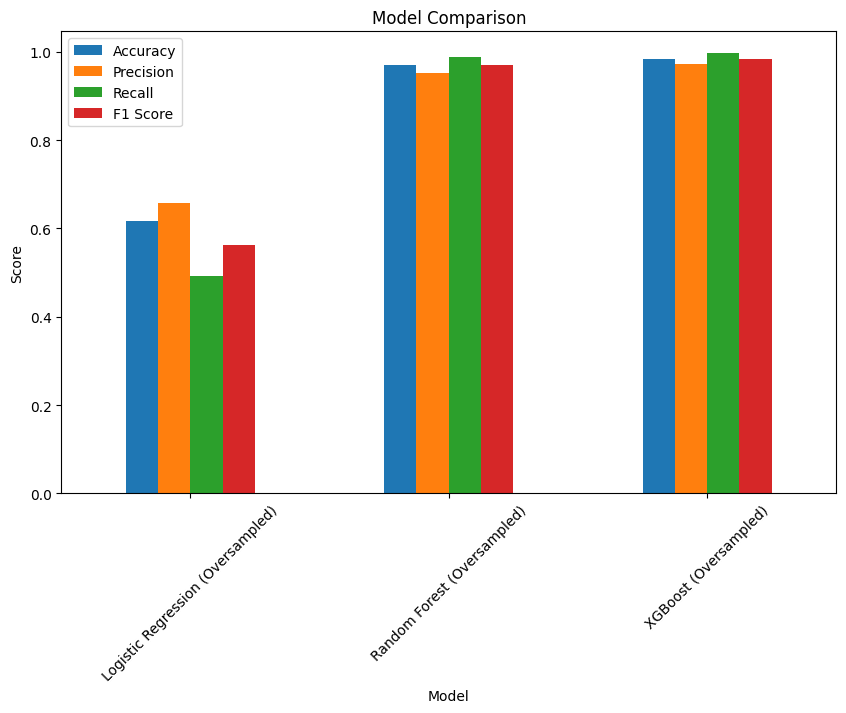

In [104]:
comparison_df.set_index("Model")[["Accuracy","Precision","Recall","F1 Score",]].plot(kind="bar", figsize=(10,6))
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()

#SHAP

In [107]:
# Create SHAP explainer for the best tree-based model and compute SHAP values for the test data
import shap
explainer = shap.TreeExplainer(g.best_estimator_)
shap_values = explainer.shap_values(x_test_os)


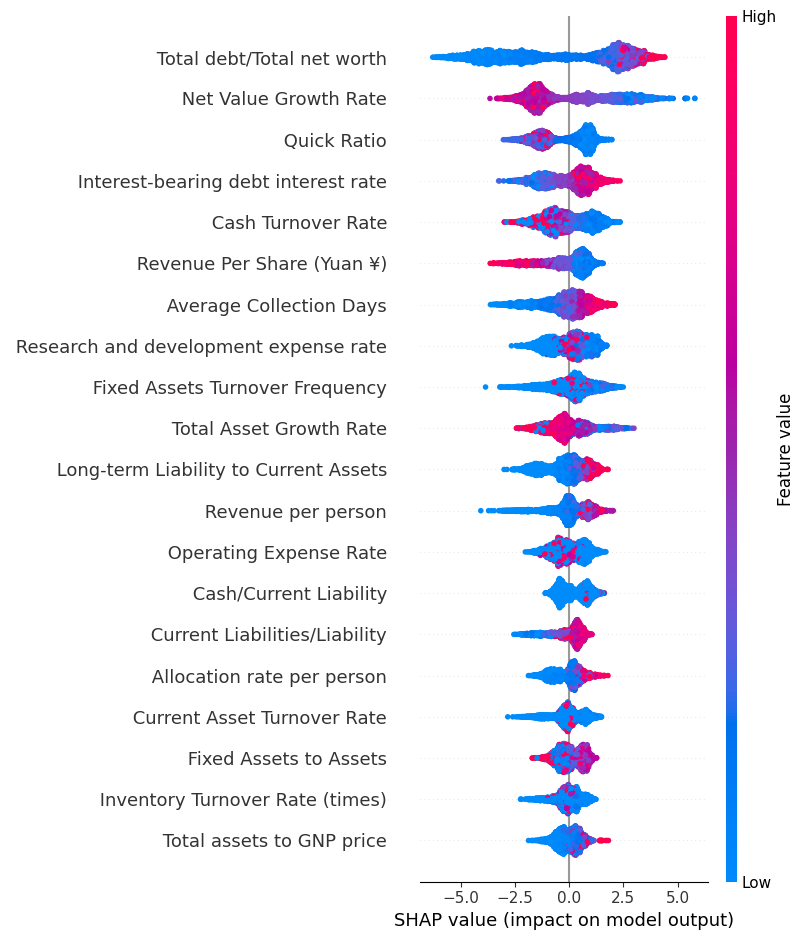

In [108]:
shap.summary_plot(shap_values, x_test_os)

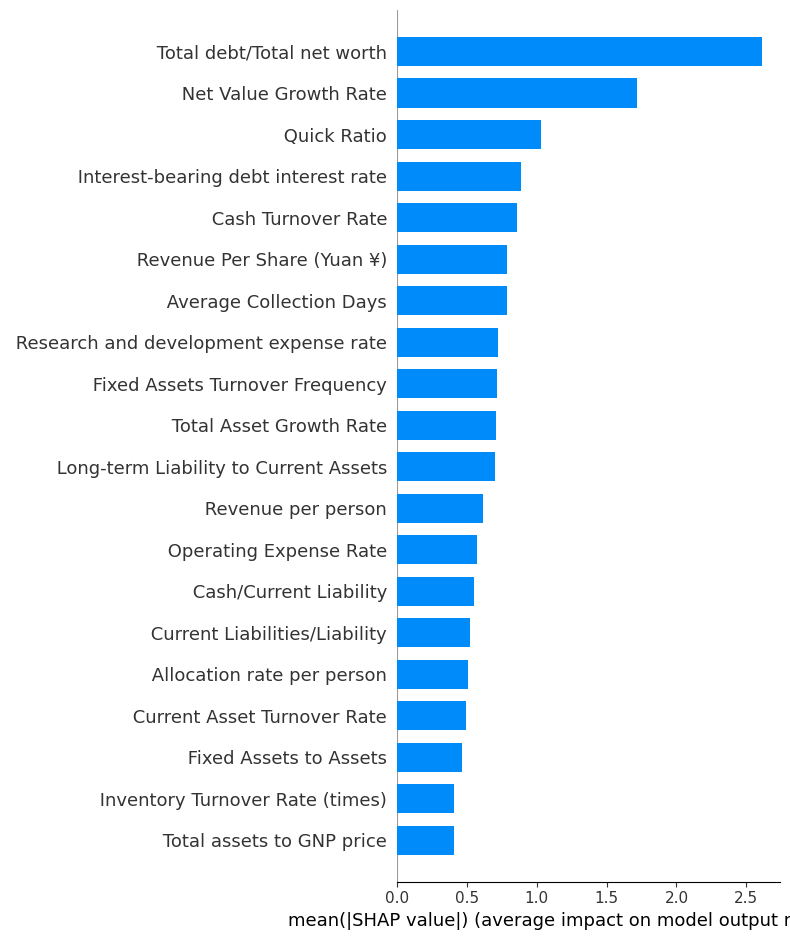

In [109]:
shap.summary_plot(shap_values, x_test_os, plot_type="bar")


# Feature importance

In [110]:
feature_importance = pd.DataFrame({
    'Feature': x_train.columns,
    'Importance': g.best_estimator_.feature_importances_
})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)


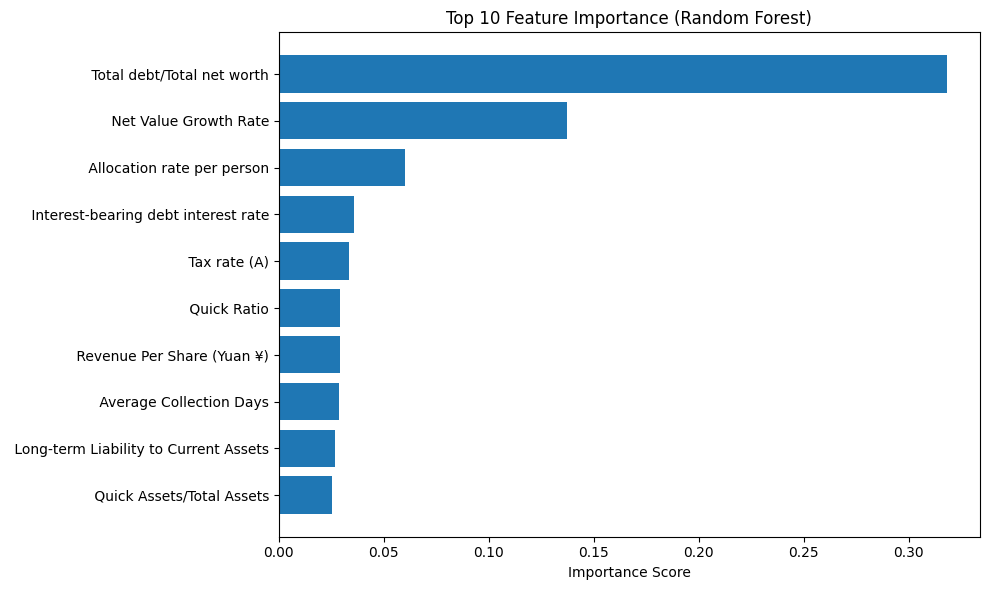

In [111]:
# Select top 10 important features
top_features = feature_importance.head(10)
plt.figure(figsize=(10,6))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.gca().invert_yaxis()
plt.xlabel('Importance Score')
plt.title('Top 10 Feature Importance (Random Forest)')
plt.tight_layout()
plt.show()


# Conclusion